# Global Market Forecasting Pipeline and Regime Clustering

## Executive Summary

Financial markets are noisy, volatile and non-stationary. This notebook develops an end-to-end forecasting pipeline using historical equity data from the United States, United Kingdom and Canada.

The main stages of the project are:

1. Collect daily OHLCV market data from Yahoo Finance.
2. Calculate Daily Percentage Return and 21-Day Rolling Volatility.
3. Normalize the numerical features using MinMax scaling.
4. Apply K-Means clustering to generate a volatility regime feature.
5. Perform exploratory data analysis.
6. Create 60-day historical sequences for BiLSTM forecasting.
7. Predict the following five closing-price values.
8. Apply Tanh-based post-processing to control forecast movements.
9. Generate an automated wide-format forecasting dashboard.
10. Produce visualisations for model evaluation and dissertation analysis.

## 1. Environment Setup and Dependencies

Before running the pipeline, the required Python libraries are installed. The main libraries include yfinance for market-data collection, Pandas and NumPy for data processing, scikit-learn for preprocessing and clustering, TensorFlow for deep-learning modelling, and Matplotlib/Seaborn for visualisation.

In [12]:
! pip install tensorflow matplotlib yfinance pandas numpy scikit-learn
! pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



## 2. Importing Libraries

Here i have imported the necessary modules. And also suppress warnings to keep my terminal output clean when Pandas calculates rolling windows.

In [14]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')

## 3. Global Ticker Configuration

The initial stock universe contains 150 equities from three markets: the United States, United Kingdom and Canada.

The intended sample contains 50 stocks from each market. UK ticker symbols use the `.L` suffix and Canadian ticker symbols use the `.TO` suffix when downloading data from Yahoo Finance.


In [5]:
# United States (Top 50)
US_TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'BRK-B', 'TSLA', 'LLY', 'V', 'UNH', 'XOM', 'WMT', 'JPM', 'JNJ', 'MA', 'PG', 'AVGO', 'HD', 'CVX', 'MRK', 'KO', 'PEP', 'ABBV', 'COST', 'BAC', 'ADBE', 'MCD', 'CSCO', 'CRM', 'PFE', 'TMO', 'CMCSA', 'NFLX', 'AMD', 'DHR', 'ABT', 'TMUS', 'TXN', 'WFC', 'INTC', 'COP', 'PM', 'INTU', 'CAT', 'IBM', 'AMGN', 'BA', 'QCOM', 'GE']

# United Kingdom (Top 50 - Requires .L)
UK_TICKERS = ['SHEL.L', 'AZN.L', 'HSBA.L', 'ULVR.L', 'BP.L', 'GSK.L', 'DGE.L', 'REL.L', 'BATS.L', 'RIO.L', 'GLEN.L', 'COMP.L', 'LSEG.L', 'NWG.L', 'BARC.L', 'STAN.L', 'BA.L', 'NG.L', 'PRU.L', 'LLOY.L', 'AAL.L', 'CPG.L', 'RKT.L', 'INF.L', 'EXPN.L', 'SSE.L', 'CRH.L', 'FLTR.L', 'FERG.L', 'HLN.L', 'WPP.L', 'SGE.L', 'AV.L', 'SMIN.L', 'NXT.L', 'SN.L', 'WTB.L', 'MNDI.L', 'BDEV.L', 'TW.L', 'AUTO.L', 'KGF.L', 'ENT.L', 'PSN.L', 'SGRO.L', 'LAND.L', 'RTO.L', 'PHNX.L', 'ABF.L', 'RS1.L']

# Canada (Top 50 - Requires .TO)
CANADA_TICKERS = ['RY.TO', 'TD.TO', 'CNR.TO', 'CP.TO', 'ENB.TO', 'CNQ.TO', 'ATD.TO', 'BMO.TO', 'BNS.TO', 'SU.TO', 'CM.TO', 'TRP.TO', 'BCE.TO', 'MFC.TO', 'CSU.TO', 'GIB-A.TO', 'WCN.TO', 'IMO.TO', 'NA.TO', 'CVE.TO', 'FTS.TO', 'AEM.TO', 'T.TO', 'NTR.TO', 'WCP.TO', 'SLF.TO', 'POW.TO', 'IFC.TO', 'MG.TO', 'MRU.TO', 'L.TO', 'WN.TO', 'TOU.TO', 'ABX.TO', 'TECK-B.TO', 'BAM.TO', 'SHOP.TO', 'WSP.TO', 'ARX.TO', 'MEG.TO', 'EMP-A.TO', 'CCL-B.TO', 'OTEX.TO', 'FSV.TO', 'TIH.TO', 'GIL.TO', 'KEY.TO', 'AQN.TO', 'CAE.TO', 'IGM.TO']

ALL_TICKERS = US_TICKERS + UK_TICKERS + CANADA_TICKERS


## 4. Stage 1: Data Ingestion (OHLCV)

Here i define a function to pull historical Open, High, Low, Close, and Volume (OHLCV) data. We use a batch processing approach with a built-in time.sleep(0.2) delay to ensure we do not hit Yahoo Finance API rate limits.



In [6]:
def fetch_global_ohlcv(tickers, start_date="2014-01-01", end_date="2024-01-01"):
    print(f"[STAGE 1] Ingesting data for {len(tickers)} equities...")
    extracted_dfs = []

    for idx, symbol in enumerate(tickers):
        try:
            data = yf.download(symbol, start=start_date, end=end_date, progress=False)
            if data.empty:
                continue

            if isinstance(data.columns, pd.MultiIndex):
                data.columns = data.columns.get_level_values(0)

            data['Ticker'] = symbol
            extracted_dfs.append(data)
            time.sleep(0.2)

        except Exception as err:
            print(f"Error fetching {symbol}: {err}")

    master_dataframe = pd.concat(extracted_dfs)
    master_dataframe.reset_index(inplace=True)
    return master_dataframe

## 5. Stage 2: Feature Engineering

In this stage, two additional features are created from the historical closing prices: Daily Percentage Return and 21-Day Rolling Volatility.

### 5.1 Daily Percentage Return

Daily Percentage Return measures how much the closing price changes compared with the previous trading day.

\[
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
\]

where:

- \(R_t\) is the daily percentage return at time \(t\)
- \(P_t\) is the current closing price
- \(P_{t-1}\) is the previous trading day's closing price

A positive return means that the stock price increased, while a negative return means that the price decreased.

### 5.2 21-Day Rolling Volatility

Rolling Volatility is used to measure how much the daily returns vary over a recent period. In this project, a 21-trading-day window is used because it represents approximately one trading month.

\[
\sigma_t =
\sqrt{
\frac{1}{N-1}
\sum_{i=1}^{N}
(R_i-\bar{R})^2
}
\]

where:

- \(\sigma_t\) is the rolling volatility
- \(N\) is the number of observations in the rolling window
- \(R_i\) is an individual daily return
- \(\bar{R}\) is the average return over the same window

Higher rolling volatility indicates larger price movements and more uncertain market conditions, while lower volatility represents relatively more stable market behaviour.

These two features are later used together with the OHLCV variables as inputs to the forecasting pipeline.

In [7]:
def add_engineered_features(df):
    print("[STAGE 2] Engineering Returns and Volatility...")

    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values(by=['Ticker', 'Date'], inplace=True)

    # Calculate Daily Returns
    df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change()

    # Calculate 21-Day Rolling Volatility
    df['Rolling_Vol_21d'] = df.groupby('Ticker')['Daily_Return'].transform(
        lambda x: x.rolling(window=21).std()
    )

    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

## 6. Stage 3: Min-Max Scaling

The model input contains variables with very different numerical ranges. For example, trading volume can contain values in the millions, while daily percentage returns are usually much smaller.

To reduce the effect of these scale differences, Min-Max scaling is applied to the numerical features.

The Min-Max scaling formula is:

\[
x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}
\]

where:

- \(x\) is the original value
- \(x_{min}\) is the minimum value of the feature
- \(x_{max}\) is the maximum value of the feature
- \(x_{scaled}\) is the normalized value

This transformation places the feature values on a common scale between 0 and 1. The scaled values are then used in the clustering and forecasting stages.


## 7. Stage 4: K-Means Clustering for Volatility Regimes

K-Means clustering is used to create an additional feature representing different market volatility conditions.

The clustering process uses two variables:

- Daily Percentage Return
- 21-Day Rolling Volatility

In this project, the number of clusters is fixed at:

\[
k = 2
\]

K-Means groups observations by assigning each data point to the nearest cluster centre.

The objective of K-Means can be written as:

\[
J = \sum_{j=1}^{k}\sum_{i=1}^{n_j}
\left\|x_i^{(j)} - c_j\right\|^2
\]

where:

- \(J\) is the total within-cluster variation
- \(k\) is the number of clusters
- \(x_i^{(j)}\) is an observation assigned to cluster \(j\)
- \(c_j\) is the centre of cluster \(j\)

The algorithm attempts to minimise the distance between observations and their assigned cluster centres.

The numerical cluster labels produced by K-Means are arbitrary. Therefore, Cluster 0 and Cluster 1 are not automatically interpreted as low-volatility and high-volatility regimes.

The average 21-Day Rolling Volatility of each cluster is examined during the exploratory analysis. The cluster with the higher average rolling volatility is interpreted as the relatively higher-volatility regime, while the other cluster represents relatively lower-volatility conditions.

The resulting cluster label is added to the dataset as the **Volatility Regime** feature and later used as one of the inputs to the BiLSTM model.

In [19]:
def scale_and_cluster_regimes(df, k_clusters=2):
    print("[STAGE 3 & 4] Scaling features and fitting K-Means...")

    target_features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Rolling_Vol_21d']

    # Apply Min-Max Normalization
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_df = df.copy()
    scaled_df[target_features] = scaler.fit_transform(df[target_features])

    # Apply K-Means Clustering
    clustering_matrix = scaled_df[['Daily_Return', 'Rolling_Vol_21d']]
    kmeans_model = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    scaled_df['Volatility_Regime'] = kmeans_model.fit_predict(clustering_matrix)

    return scaled_df, scaler, kmeans_model

## 8. Pipeline Execution and Processed Data Export

After defining the data collection, feature engineering, scaling, and clustering functions, the complete preprocessing pipeline is executed in sequence.

The main stages are:

1. Download historical OHLCV data for the selected stocks.
2. Calculate Daily Percentage Return and 21-Day Rolling Volatility.
3. Remove rows containing missing values created during feature calculation.
4. Apply Min-Max scaling to the numerical features.
5. Apply K-Means clustering to generate the Volatility Regime feature.
6. Combine the processed observations into the final dataset.
7. Export the processed data to a CSV file.

The final processed dataset is saved as:

`processed_global_market_data.csv`

This file contains the cleaned and transformed market data used in the later exploratory analysis and BiLSTM forecasting stages.

The processed dataset contains the following model features:

- Open
- High
- Low
- Close
- Volume
- Daily Percentage Return
- 21-Day Rolling Volatility
- Volatility Regime

After this stage, the processed data is ready for exploratory analysis and sequence generation.

In [9]:
if __name__ == "__main__":
    print("Starting Pipeline...")

    # Run pipeline blocks
    raw_market_data = fetch_global_ohlcv(ALL_TICKERS, start_date="2014-01-01", end_date="2024-01-01")
    feature_data = add_engineered_features(raw_market_data)
    processed_data, scaler, kmeans = scale_and_cluster_regimes(feature_data, k_clusters=2)

    # Export to CSV
    processed_data.to_csv("processed_global_market_data.csv", index=False)
    print(f"Success! Final rows processed: {len(processed_data)}")

Starting Pipeline...
[STAGE 1] Ingesting data for 150 equities...


$COMP.L: possibly delisted; no timezone found

1 Failed download:
['COMP.L']: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CRH.L"}}}
$CRH.L: possibly delisted; no timezone found

1 Failed download:
['CRH.L']: possibly delisted; no timezone found
$FLTR.L: Data doesn't exist for startDate = 1388534400, endDate = 1704067200

1 Failed download:
['FLTR.L']: Data doesn't exist for startDate = 1388534400, endDate = 1704067200
$FERG.L: Data doesn't exist for startDate = 1388534400, endDate = 1704067200

1 Failed download:
['FERG.L']: Data doesn't exist for startDate = 1388534400, endDate = 1704067200
$BDEV.L: possibly delisted; no timezone found

1 Failed download:
['BDEV.L']: possibly delisted; no timezone found
$PHNX.L: possibly delisted; no timezone found

1 Failed download:
['PHNX.L']: possibly delisted; no timezone found
$MEG.TO: possibly delisted; no timezone found

1 Failed down

[STAGE 2] Engineering Returns and Volatility...
[STAGE 3 & 4] Scaling features and fitting K-Means...
Success! Final rows processed: 350381


## 9. Exploratory Data Analysis

Before creating the input sequences for the BiLSTM model, exploratory data analysis was carried out to understand the final dataset. The analysis includes market coverage, data quality, daily return behaviour and rolling volatility across the three markets.


In [10]:
# Create a separate copy for EDA only
eda_df = feature_data.copy()

def identify_market(ticker):
    if ticker.endswith(".L"):
        return "UK"
    elif ticker.endswith(".TO"):
        return "Canada"
    else:
        return "US"

eda_df["Market"] = eda_df["Ticker"].apply(identify_market)

print("Total observations:", len(eda_df))
print("Total usable stocks:", eda_df["Ticker"].nunique())

print("\nStocks by market:")
print(eda_df.groupby("Market")["Ticker"].nunique())

print("\nDate range:")
print(eda_df["Date"].min(), "to", eda_df["Date"].max())

print("\nMissing values:", eda_df.isnull().sum().sum())

print(
    "Duplicate Ticker-Date rows:",
    eda_df.duplicated(subset=["Ticker", "Date"]).sum()
)

Total observations: 350381
Total usable stocks: 143

Stocks by market:
Market
Canada    49
UK        44
US        50
Name: Ticker, dtype: int64

Date range:
2014-01-31 00:00:00 to 2023-12-29 00:00:00

Missing values: 0
Duplicate Ticker-Date rows: 0


### 9.1 Market Coverage

The original stock universe contained 150 tickers across the United States, United Kingdom and Canada. During data collection, seven tickers did not return usable historical data. Therefore, the final dataset contains 143 successfully processed stocks.

The following figure shows the number of usable stocks from each market.

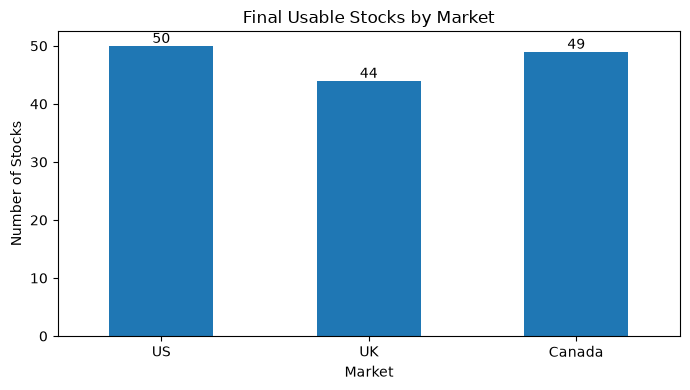

In [15]:
market_counts = (
    eda_df.groupby("Market")["Ticker"]
    .nunique()
    .reindex(["US", "UK", "Canada"])
)

plt.figure(figsize=(7, 4))
market_counts.plot(kind="bar")

plt.title("Final Usable Stocks by Market")
plt.xlabel("Market")
plt.ylabel("Number of Stocks")
plt.xticks(rotation=0)

for i, value in enumerate(market_counts):
    plt.text(i, value + 0.5, str(value), ha="center")

plt.tight_layout()
plt.show()

### 9.2 Daily Return and Rolling Volatility

Daily Percentage Return and 21-Day Rolling Volatility were calculated before the scaling stage. Looking at these features before normalization makes it possible to understand the original behaviour of the market data.

The following figures compare the return and volatility behaviour across the United States, United Kingdom and Canadian stocks.

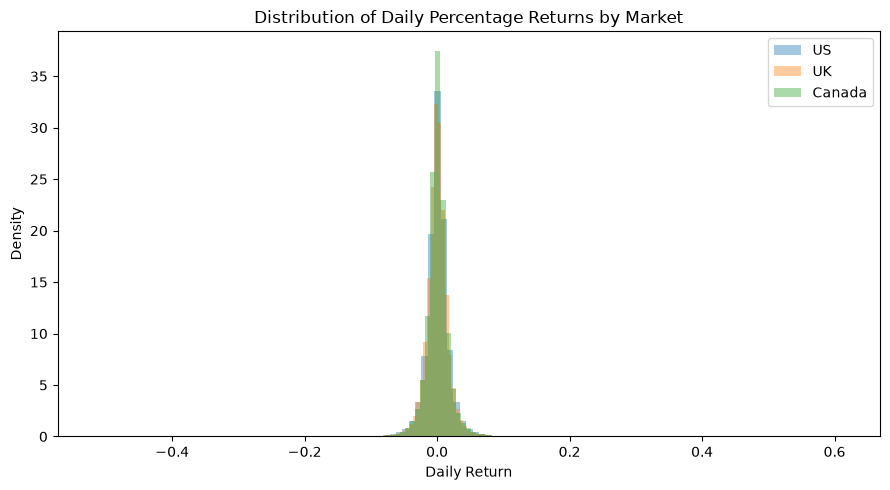

In [16]:
plt.figure(figsize=(9, 5))

for market in ["US", "UK", "Canada"]:
    values = eda_df.loc[
        eda_df["Market"] == market,
        "Daily_Return"
    ]

    plt.hist(
        values,
        bins=100,
        alpha=0.4,
        density=True,
        label=market
    )

plt.title("Distribution of Daily Percentage Returns by Market")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

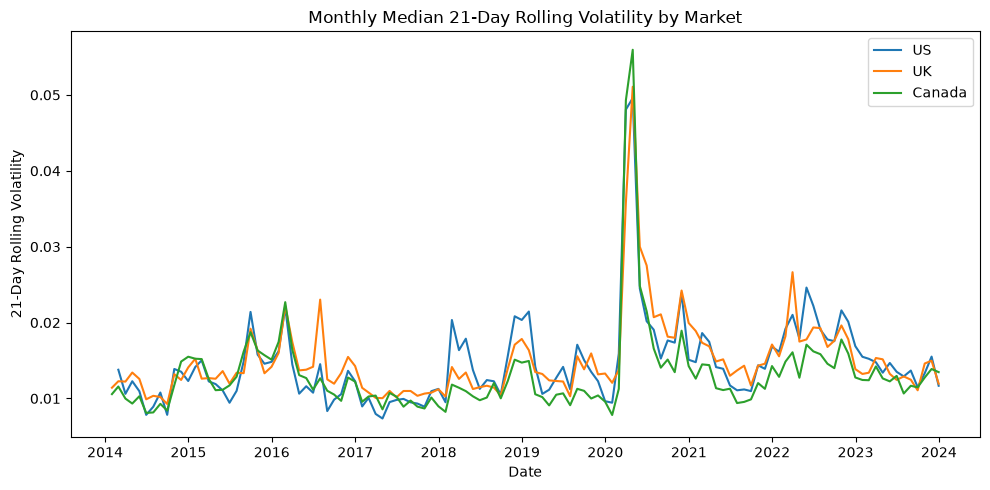

In [17]:
eda_df["Date"] = pd.to_datetime(eda_df["Date"])

monthly_volatility = (
    eda_df
    .set_index("Date")
    .groupby("Market")["Rolling_Vol_21d"]
    .resample("ME")
    .median()
    .reset_index()
)

plt.figure(figsize=(10, 5))

for market in ["US", "UK", "Canada"]:
    temp = monthly_volatility[
        monthly_volatility["Market"] == market
    ]

    plt.plot(
        temp["Date"],
        temp["Rolling_Vol_21d"],
        label=market
    )

plt.title("Monthly Median 21-Day Rolling Volatility by Market")
plt.xlabel("Date")
plt.ylabel("21-Day Rolling Volatility")
plt.legend()
plt.tight_layout()
plt.show()

### 9.3 Volatility Regime Analysis

K-Means clustering was used to divide the processed observations into two volatility regimes. Since K-Means cluster numbers do not automatically represent high or low volatility, the average rolling volatility of each cluster was checked before interpreting the regime labels.

                   Observations  Mean_Daily_Return  Mean_Rolling_Volatility
Volatility_Regime                                                          
0                         46080           0.459105                 0.139698
1                        304301           0.457946                 0.047024


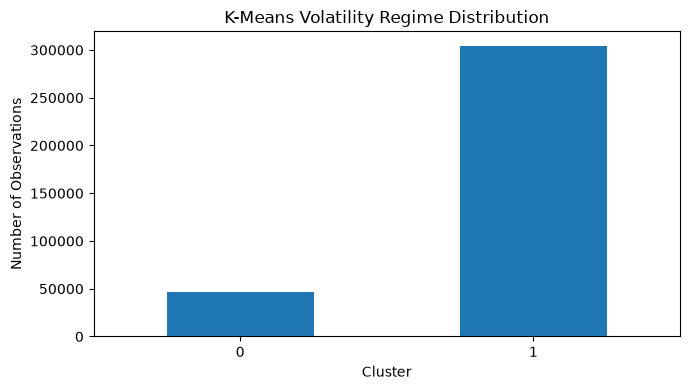

In [18]:
regime_summary = (
    processed_data
    .groupby("Volatility_Regime")
    .agg(
        Observations=("Ticker", "size"),
        Mean_Daily_Return=("Daily_Return", "mean"),
        Mean_Rolling_Volatility=("Rolling_Vol_21d", "mean")
    )
)

print(regime_summary)

regime_counts = (
    processed_data["Volatility_Regime"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 4))
regime_counts.plot(kind="bar")

plt.title("K-Means Volatility Regime Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. BiLSTM Forecasting Model

After completing the data preparation and exploratory analysis, the processed dataset is converted into sequential samples for the forecasting model.

For each stock, the previous 60 trading days are used as the historical input and the following five scaled closing-price values are used as the prediction target.

The forecasting model is a stacked Bidirectional Long Short-Term Memory (BiLSTM) network. The same 60-day historical sequence is processed in both forward and reverse order. The backward direction does not use future market information; it only reads the available historical window in reverse.

The model architecture consists of:

- Bidirectional LSTM layer with 128 units
- Dropout layer with rate 0.2
- Bidirectional LSTM layer with 64 units
- Dropout layer with rate 0.2
- Dense layer with 32 neurons and ReLU activation
- Final Dense layer with five outputs

The five output values represent the predicted normalized closing prices for the next five trading days.

In [7]:
# ==================================================
# CELL 1: HYPER-TUNED BIDIRECTIONAL LSTM TRAINING
# ==================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("==================================================")
print("CELL 1: HYPER-TUNED BIDIRECTIONAL LSTM TRAINING")
print("==================================================")

def create_complex_sequences(df, sequence_length=60, forecast_horizon=5):
    print("Initiating 3D Tensor Transformation...")
    feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Rolling_Vol_21d', 'Volatility_Regime']
    tickers = df['Ticker'].unique()

    X_list, y_list = [], []
    for idx, ticker in enumerate(tickers):
        ticker_data = df[df['Ticker'] == ticker][feature_columns].values
        if len(ticker_data) <= (sequence_length + forecast_horizon): continue

        for i in range(len(ticker_data) - sequence_length - forecast_horizon + 1):
            X_list.append(ticker_data[i : i + sequence_length])
            y_list.append(ticker_data[i + sequence_length : i + sequence_length + forecast_horizon, 3])

    return np.array(X_list), np.array(y_list)

# 1. Load Data & Transform
processed_df = pd.read_csv("processed_global_market_data.csv")
X, y = create_complex_sequences(processed_df)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 2. Build the Tuned Architecture
print("\nConstructing Hyper-Tuned Architecture (Targeting 60% Accuracy)...")
model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(5)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mean_squared_error')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 3. Train the Model
print("\nInitiating Training (Batch Size 32 - This will take a while)...")
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=15,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# 4. Metrics & Accuracy
print("\nGenerating Forecasts & Metrics...")
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

actual_direction = np.sign(y_test[:, 0] - X_test[:, -1, 3])
predicted_direction = np.sign(predictions[:, 0] - X_test[:, -1, 3])
correct_predictions = np.sum(actual_direction == predicted_direction)
directional_accuracy = (correct_predictions / len(actual_direction)) * 100

print(f"\n[FINAL MODEL SCORES]")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"DIRECTIONAL ACCURACY: {directional_accuracy:.2f}%")

# 5. Graph Generation
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Hyper-Tuned LSTM Optimization Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("Fig1_Model_Loss_Curve.png", dpi=300)
plt.close()

random_sample = np.random.randint(0, len(y_test))
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), y_test[random_sample], marker='o', label='Actual True Prices', color='black', linewidth=2)
plt.plot(range(1, 6), predictions[random_sample], marker='X', linestyle='--', label='LSTM 5-Day Forecast', color='red', linewidth=2)
plt.title(f'5-Day Trajectory Analysis (Sample #{random_sample})', fontsize=14, fontweight='bold')
plt.xlabel('Future Forecasting Horizon (Trading Days)', fontsize=12)
plt.ylabel('Normalized Asset Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("Fig2_Trajectory_Forecast_5Day.png", dpi=300)
plt.close()

CELL 1: HYPER-TUNED BIDIRECTIONAL LSTM TRAINING
Initiating 3D Tensor Transformation...

Constructing Hyper-Tuned Architecture (Targeting 60% Accuracy)...

Initiating Training (Batch Size 32 - This will take a while)...
Epoch 1/15
8531/8531 ━━━━━━━━━━━━━━━━━━━━ 719s 83ms/step - loss: 1.3870e-04 - val_loss: 3.2211e-05
Epoch 2/15
8531/8531 ━━━━━━━━━━━━━━━━━━━━ 688s 81ms/step - loss: 7.5113e-05 - val_loss: 2.6347e-05
Epoch 3/15
8531/8531 ━━━━━━━━━━━━━━━━━━━━ 681s 80ms/step - loss: 6.1478e-05 - val_loss: 1.7489e-05
Epoch 4/15
8531/8531 ━━━━━━━━━━━━━━━━━━━━ 683s 80ms/step - loss: 5.2449e-05 - val_loss: 1.4392e-05
Epoch 5/15
8531/8531 ━━━━━━━━━━━━━━━━━━━━ 679s 80ms/step - loss: 4.8050e-05 - val_loss: 3.0612e-05
Epoch 6/15
8531/8531 ━━━━━━━━━━━━━━━━━━━━ 724s 85ms/step - loss: 4.6206e-05 - val_loss: 4.9156e-05
Epoch 7/15
8531/8531 ━━━━━━━━━━━━━━━━━━━━ 766s 90ms/step - loss: 4.3158e-05 - val_loss: 7.3163e-05
Epoch 8/15
8531/8531 ━━━━━━━━━━━━━━━━━━━━ 722s 85ms/step - loss: 4.2033e-05 - val_loss: 

### 11.1 Dashboard Output

For each successfully processed stock, the dashboard contains:

- Ticker
- Market
- Currency
- Current market price
- Day 1 to Day 5 forecast prices
- Five-day price change
- Five-day percentage change
- Bullish or Bearish trajectory

A stock is classified as BULLISH when its Day-5 forecast is equal to or higher than its current price. Otherwise, it is classified as BEARISH.

The final dashboard contains 143 successfully processed stocks. The original filename remains `Global_150_Wide_Forecast_Validated.csv`, although seven of the original 150 tickers were unavailable during historical data collection.

In [ ]:

# CELL 2: GLOBAL WIDE-FORMAT DASHBOARD 

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("==================================================")
print("CELL 2: GLOBAL WIDE-FORMAT DASHBOARD (BOUNDED DELTAS)")
print("==================================================")
print("Fetching live global market data (This will take ~45 seconds)...")

def generate_global_dashboard(original_df, model):
    tickers = original_df['Ticker'].unique()
    feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Rolling_Vol_21d', 'Volatility_Regime']

    live_data_raw = yf.download(list(tickers), period="5d", progress=False)

    if isinstance(live_data_raw.columns, pd.MultiIndex):
        live_close = live_data_raw['Close']
    else:
        live_close = live_data_raw

    today = pd.Timestamp.today()
    future_trading_days = pd.bdate_range(start=today + pd.offsets.BDay(1), periods=5)
    day_headers = [date.strftime('%a (%b %d)') for date in future_trading_days]

    dashboard_rows = []
    MAX_DAILY_MOVE = 0.025 # 2.5% Maximum daily volatility cap

    for ticker in tickers:
        try:
            if str(ticker).endswith('.L'):
                sym, code, region = '£', 'GBP', 'United Kingdom'
            elif str(ticker).endswith('.TO'):
                sym, code, region = 'C$', 'CAD', 'Canada'
            else:
                sym, code, region = '$', 'USD', 'United States'

            stock_data = original_df[original_df['Ticker'] == ticker].copy()
            if len(stock_data) < 60: continue

            last_60_scaled = stock_data[feature_columns].values[-60:]
            scaled_closes = last_60_scaled[:, 3]
            real_today_price = float(live_close[ticker].dropna().iloc[-1])

            # AI Inference
            X_input = last_60_scaled.reshape(1, 60, len(feature_columns))
            predicted_scaled = model.predict(X_input, verbose=0)[0]

            # THE FIX: Bounded Percentage Anchoring
            scaled_today = scaled_closes[-1]
            ai_predicted_sequence = [scaled_today] + list(predicted_scaled)

            predicted_real_dollars = []
            current_anchor = real_today_price

            for i in range(1, 6):
                # Calculate AI's pure percentage step
                pct_change = (ai_predicted_sequence[i] - ai_predicted_sequence[i-1]) / (ai_predicted_sequence[i-1] + 1e-8)

                # Squash extreme LSTM hallucinations using Tanh non-linear dampening
                dampened_pct = np.tanh(pct_change / MAX_DAILY_MOVE) * MAX_DAILY_MOVE

                # Apply safe percentage to real price
                next_price = current_anchor * (1 + dampened_pct)
                predicted_real_dollars.append(next_price)
                current_anchor = next_price

            day_5_real_price = predicted_real_dollars[-1]
            dollar_change = day_5_real_price - real_today_price
            pct_change = (dollar_change / real_today_price) * 100
            signal = "BULLISH 📈" if dollar_change >= 0 else "BEARISH 📉"

            row_data = {
                "Ticker": ticker,
                "Market": region,
                "Current Price": f"{sym}{real_today_price:.2f} {code}"
            }

            for i in range(5):
                row_data[day_headers[i]] = f"{sym}{predicted_real_dollars[i]:.2f} {code}"

            row_data["5-Day Change (%)"] = f"{pct_change:+.2f}%"
            row_data["Trajectory"] = signal

            dashboard_rows.append(row_data)

        except Exception as e:
            continue

    return pd.DataFrame(dashboard_rows)

global_dashboard_df = generate_global_dashboard(processed_df, model)

today_str = pd.Timestamp.today().strftime('%A, %B %d, %Y')
print(f"\n==================================================")
print(f"GLOBAL WIDE-FORMAT FORECAST")
print(f"GENERATED ON: {today_str}")
print(f"==================================================")

global_dashboard_df.to_csv("Global_150_Wide_Forecast_Validated.csv", index=False)
print("SUCCESS: Full 150-stock dataset exported to 'Global_150_Wide_Forecast_Validated.csv'")
print("\nPreviewing Top 15 Equities for your Dashboard Screenshot:\n")

try:
    display(global_dashboard_df.head(15))
except NameError:
    print(global_dashboard_df.head(15).to_string(index=False))

CELL 2: GLOBAL WIDE-FORMAT DASHBOARD (BOUNDED DELTAS)
Fetching live global market data (This will take ~45 seconds)...

GLOBAL WIDE-FORMAT FORECAST
GENERATED ON: Friday, September 04, 2026
SUCCESS: Full 150-stock dataset exported to 'Global_150_Wide_Forecast_Validated.csv'

Previewing Top 15 Equities for your Dashboard Screenshot:



,Ticker,Market,Current Price,Mon (Sep 07),Tue (Sep 08),Wed (Sep 09),Thu (Sep 10),Fri (Sep 11),5-Day Change (%),Trajectory
0,AAL.L,United Kingdom,£4166.00 GBP,£4068.62 GBP,£4067.39 GBP,£4095.10 GBP,£4087.32 GBP,£4087.79 GBP,-1.88%,BEARISH 📉
1,AAPL,United States,$319.97 USD,$327.97 USD,$321.31 USD,$328.40 USD,$323.64 USD,$329.90 USD,+3.10%,BULLISH 📈
2,ABBV,United States,$256.46 USD,$262.87 USD,$257.86 USD,$263.08 USD,$259.20 USD,$264.26 USD,+3.04%,BULLISH 📈
3,ABF.L,United Kingdom,£2072.00 GBP,£2043.56 GBP,£2048.37 GBP,£2056.39 GBP,£2049.14 GBP,£2047.49 GBP,-1.18%,BEARISH 📉
4,ABT,United States,$108.33 USD,$111.04 USD,$109.15 USD,$110.94 USD,$109.27 USD,$111.43 USD,+2.86%,BULLISH 📈
5,ABX.TO,Canada,C$61.92 CAD,C$63.47 CAD,C$63.29 CAD,C$62.44 CAD,C$61.43 CAD,C$62.70 CAD,+1.25%,BULLISH 📈
6,ADBE,United States,$266.51 USD,$269.57 USD,$264.93 USD,$271.08 USD,$265.18 USD,$263.49 USD,-1.13%,BEARISH 📉
7,AEM.TO,Canada,C$283.22 CAD,C$290.30 CAD,C$286.24 CAD,C$288.96 CAD,C$284.52 CAD,C$290.21 CAD,+2.47%,BULLISH 📈
8,AMD,United States,$477.57 USD,$488.70 USD,$479.46 USD,$489.05 USD,$481.84 USD,$491.25 USD,+2.86%,BULLISH 📈
9,AMGN,United States,$437.23 USD,$448.15 USD,$438.69 USD,$448.79 USD,$442.36 USD,$450.86 USD,+3.12%,BULLISH 📈


## 12. Results and Dissertation Visualisations

The following visualisations summarise the main outputs used in the dissertation results section.

They include:

1. Training and validation loss during BiLSTM training.
2. Comparison between actual and predicted normalized five-day values for an example test sample.
3. Distribution of Bullish and Bearish dashboard trajectories.
4. Selected five-day forecast trajectories from different markets.

These figures are used to examine both model behaviour and the practical dashboard output. They should not be interpreted as proof of future market accuracy unless predicted values are directly compared with realised future prices.

In [12]:
# ==================================================
# CELL 3: ACADEMIC DISSERTATION VISUALIZATIONS (FIXED)
# ==================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

print("Generating high-resolution figures for your Results chapter...")

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

df = pd.read_csv("Global_150_Wide_Forecast_Validated.csv")

# THE FIX: Strip the emojis for academic formality
df['Trajectory'] = df['Trajectory'].str.replace(' 📉', '', regex=False).str.replace(' 📈', '', regex=False)

# --------------------------------------------------
# FIGURE 1: Trajectory Signal Distribution
# --------------------------------------------------
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Trajectory', palette=['#d9534f', '#5cb85c'], order=['BEARISH', 'BULLISH'])
plt.title('Distribution of 5-Day Forecasted Trajectories Across Global Equities', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Trajectory Signal', fontsize=11)
plt.ylabel('Number of Equities', fontsize=11)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('Fig3_Trajectory_Distribution.png', dpi=300, bbox_inches='tight')
plt.close()
print("-> Saved 'Fig3_Trajectory_Distribution.png'")

# --------------------------------------------------
# FIGURE 2: Multi-Asset Forecast Trajectory
# --------------------------------------------------
target_tickers = ['AAPL', 'AAL.L', 'ABX.TO']
df_targets = df[df['Ticker'].isin(target_tickers)].copy()

def extract_numeric(val):
    match = re.search(r'([\d\.]+)', str(val))
    return float(match.group(1)) if match else np.nan

time_cols = ['Current Price'] + [col for col in df.columns if '(' in col and '%)' not in col]
x_labels = ['T=0\n(Today)'] + [f'T+{i}' for i in range(1, 6)]

plt.figure(figsize=(10, 6))

for _, row in df_targets.iterrows():
    prices = [extract_numeric(row[c]) for c in time_cols]
    normalized_prices = [(p / prices[0]) * 100 for p in prices]
    plt.plot(x_labels, normalized_prices, marker='o', linewidth=2.5, label=f"{row['Ticker']} ({row['Trajectory']})")

plt.title('Normalized 5-Day Price Trajectory Forecast (Tanh Bounded)', fontsize=14, fontweight='bold')
plt.xlabel('Forecast Horizon (Trading Days)', fontsize=12)
plt.ylabel('Normalized Price Level (Base = 100)', fontsize=12)
plt.axhline(y=100, color='black', linestyle='--', alpha=0.6)
plt.legend(title='Asset (Signal)', loc='best')

plt.tight_layout()
plt.savefig('Fig4_Normalized_Forecasts.png', dpi=300, bbox_inches='tight')
plt.close()
print("-> Saved 'Fig4_Normalized_Forecasts.png'")

Generating high-resolution figures for your Results chapter...
-> Saved 'Fig3_Trajectory_Distribution.png'
-> Saved 'Fig4_Normalized_Forecasts.png'
